In [1]:
from UHI_statistics import *
from Montreal_UHI_toolbox import *
import plotly.graph_objects as go

/runoff/gulley/.miniconda3/lib/python3.12/site-packages/gribapi/__init__.py:23: UserWarning: ecCodes 2.39.0 or higher is recommended. You are running version 2.14.1
  warnings.warn(


In [35]:
fig = go.Figure()

N = 11 # 11 contiguous heatwave events
means_hwd = []
errors_hwd = []
# The UHI during registered heat wave days is different than the weighted UHI for registered heat days therefore the former can be selected for as well
for field,model in zip(['tasmin_S','tasmin_T', 'tasmin_C'],['Observation','TEB+CLASS', 'CLASS']):
    # Load tasmin for each model 
    rural_hwd = temps_daily[field].sel(time=registered_heat_days).sel(station=obs_rural.station)
    urban_hwd = temps_daily[field].sel(time=registered_heat_days).sel(station=obs_urban.station)
    UHI_hwd = urban_hwd.mean(dim='station') - rural_hwd.mean(dim='station')
    UHI_hwd_mean = UHI_hwd.mean(dim='time')
    UHI_hwd_err = UHI_hwd.std(dim='time')/np.sqrt(n) * stats.t.ppf(1 - alpha/2, N-1)

    means_hwd.append(np.round(float(UHI_hwd_mean.values),2))
    errors_hwd.append(np.round(float(UHI_hwd_err.values),2))


In [45]:
weighted = False

weighted_text = ''
labels  = ['Observation', 'TEB+CLASS', 'CLASS']

# Tasmin during heat wave days could be pulled from other sources, but it was faster just to round then copy from the spreadsheet. 
# For more info see savers/heat_wave_days.ipynb, UHI_statics.py, and HW days google sheets

if weighted:
    means_hwd   = [2.28, 2.51, 0.54]
    errors_hwd  = [0.68, 0.71, 0.49]
    weighted_text = 'Weighted '

means_jja = [2.15,2.05, 0.21]
errors_jja = [0.13,0.09,0.06]

means = np.round(np.array(means_hwd) - np.array(means_jja),2)
errors = np.round(np.sqrt(np.square(errors_hwd) + np.square(errors_jja)),2)

colors  = ['black', 'red', 'blue']

fig = go.Figure()

for label, mean, err, color in zip(labels, means, errors, colors):
    fig.add_trace(go.Scatter(
        x=[mean],
        y=[label],
        marker=dict(symbol='square', size=10, color=color),
        error_x=dict(type='data', array=np.round([err],2), visible=True, color=color),
        name=label,
        showlegend=False,
        # Annotation: 'mean ± err' to the right of each whisker
        # text=[f'{mean} ± {err} °C'],
        # textposition='middle right',
        # mode='markers',
        textfont=dict(color=color, size=11),
    ))

fig.update_layout(
    title=f'Anomaly of HWD Minimum {weighted_text}Daily Temperature UHI With Respect to Summer Average',
    xaxis_title='<sup>HWD</sup><span style="text-decoration: overline;">UHI</span><sub>min</sub> - <sup>JJA</sup><span style="text-decoration: overline;">UHI</span><sub>min</sub> (°C)',
    xaxis=dict(range=[-1., 1.5]),  # extra room for text labels
    yaxis=dict(autorange='reversed'),
    font=FONT
)

fig.show()

In [4]:
# Where are the latent and sensible heat fluxes during heat waves anomalous during extreme heat periods?

# Latent heat flux 'hfls'
latent_C, latent_T = get_outputs('hfls')
# Sensible heat flux
sensible_C, sensible_T = get_outputs('hfss')

# Minimum Daily Temperatures
tasmin_C, tasmin_T = get_outputs('tasmin')

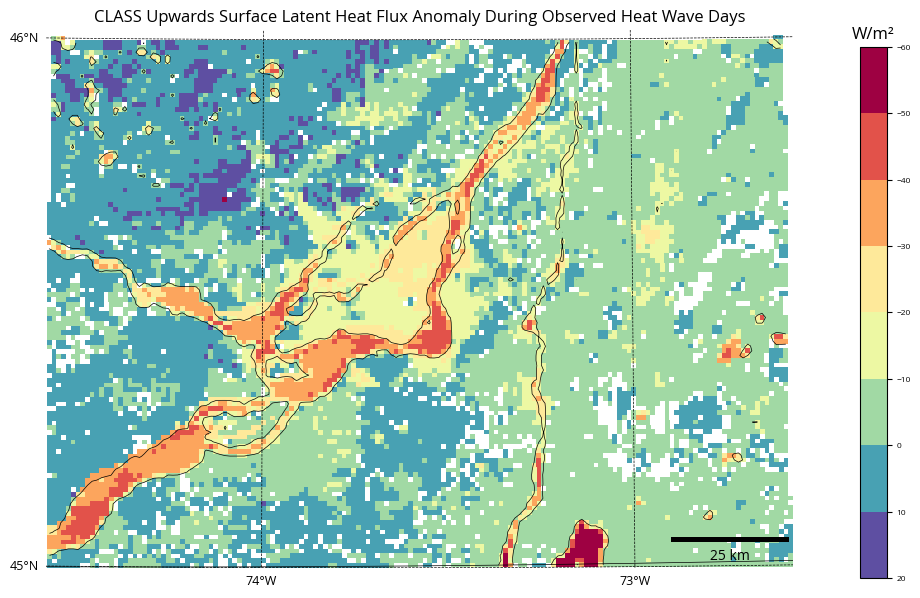

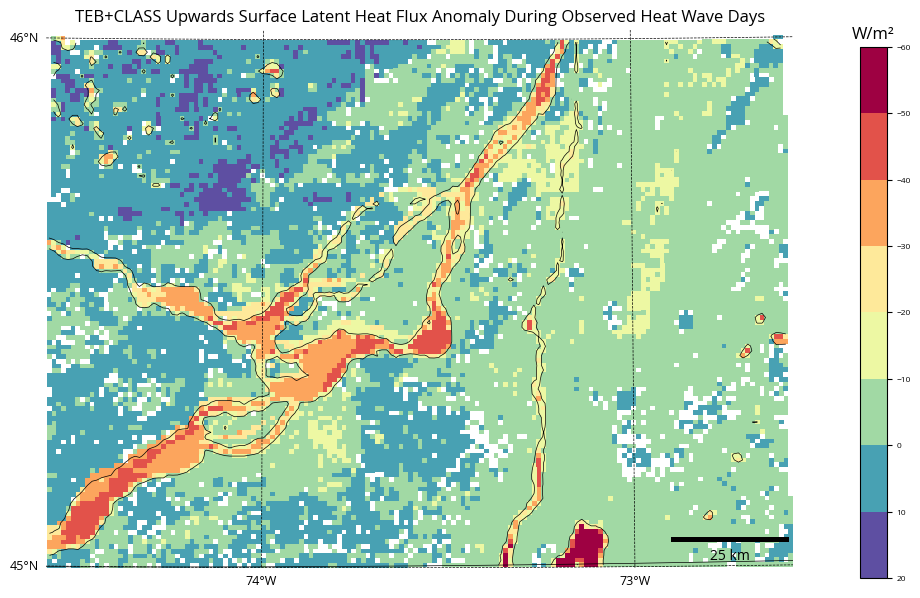

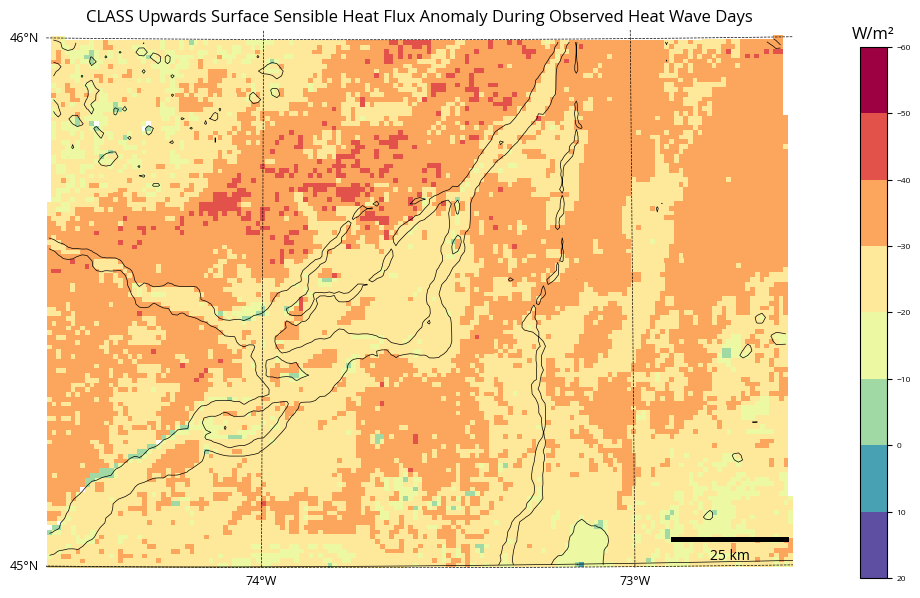

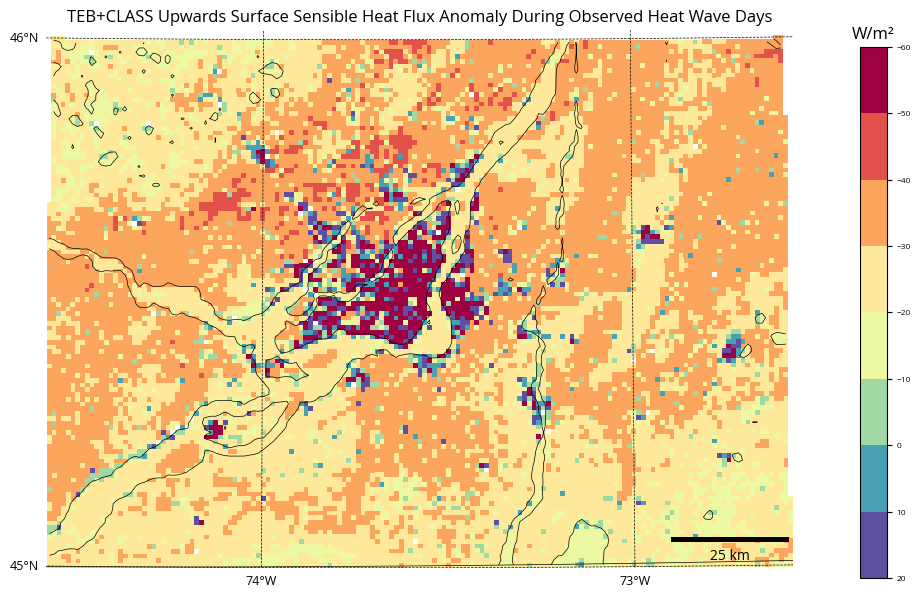

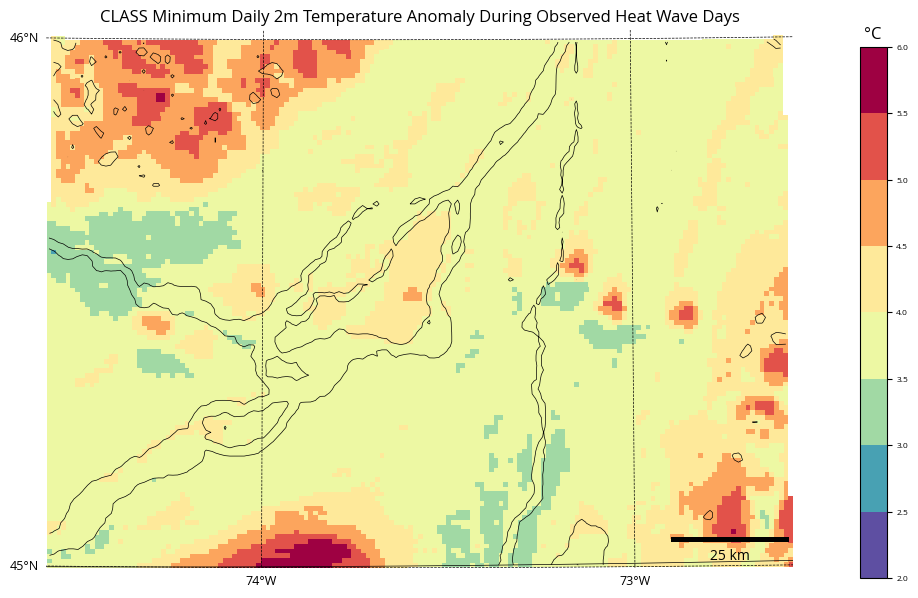

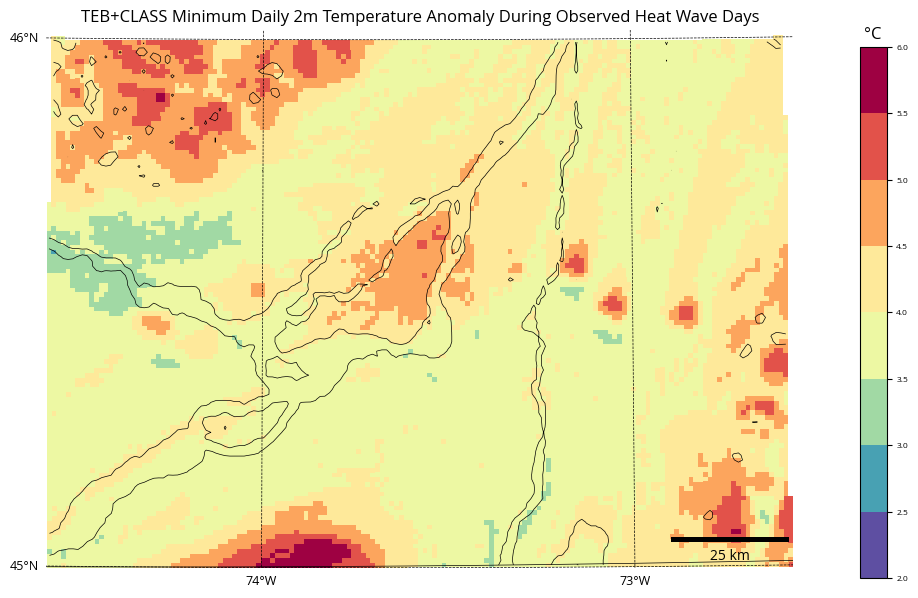

In [111]:
n = 23 # One sample per year for inter-annual variability 
alpha = 0.95 # 95% CI

for field, name, model, vmin, vmax, units in zip([latent_C, latent_T, sensible_C, sensible_T, tasmin_C, tasmin_T],
                                ['Upwards Surface Latent Heat Flux','Upwards Surface Latent Heat Flux', 'Upwards Surface Sensible Heat Flux', 'Upwards Surface Sensible Heat Flux', 'Minimum Daily 2m Temperature', 'Minimum Daily 2m Temperature'],
                                ['CLASS', 'TEB+CLASS', 'CLASS', 'TEB+CLASS','CLASS', 'TEB+CLASS'],
                                [ 20, 20, 20, 20, 2, 2], 
                                [-60,-60,-60,-60, 6, 6],
                                ['W/m²','W/m²','W/m²','W/m²','°C','°C']):

    # for field, name, model, colorscale, vmin, vmax, units in zip([ tasmin_T],
    #                                 [''],
    #                                 ['CLASS'],
    #                                 ['Spectral_r'],
    #                                 [None],
    #                                 [None], 
    #                                 ['C']):

    num_levels = 8 
    colorscale = 'Spectral_r'
    field_HWD = field.sel(time=registered_heat_days)
    JJA = field.groupby(['time.season','time.year']).mean(dim='time').sel(season='JJA')
        
    n_HWD   = 11                # Sampled heat wave events (not necessarily days)
    n_years = JJA.sizes['year'] # Sampled JJA's

    mean_HWD = field_HWD.mean(dim='time')
    std_HWD  = field_HWD.std(dim='time')

    mean_JJA = JJA.mean(dim='year')
    std_JJA  = JJA.std(dim='year')

    # Welch–Satterthwaite t-test from summary stats for unequal sample sizes
    result = stats.ttest_ind_from_stats(
        mean1=mean_HWD, std1=std_HWD, nobs1=n_HWD,
        mean2=mean_JJA, std2=std_JJA, nobs2=n_years,
        equal_var=False
    )

    # Anomaly during HWD versus JJA average
    anomaly = mean_HWD - mean_JJA

    # Significant anomaly (where p_val < 0.05)
    sig_CI = anomaly.where(result.pvalue < alpha)
    
    # Mask of values outside of 10-90th IPR
    sig_IPR = anomaly.where((mean_HWD<IPR.sel(quantile=0.1)) | (mean_HWD> IPR.sel(quantile=0.9)))

    # Display map
    fig, ax, cb = plot_field(sig_CI, MTL_focus=True, vmin=vmin, vmax=vmax,cmap=colorscale,num_levels=num_levels, extend='neither',feature_colours='black')
    pos = cb.ax.get_position()
    cb.ax.set_title(units)
    cb.ax.set_position([pos.x0+0.02, pos.y0+0.075, pos.width, pos.height*0.75])
    plt.title(f'{model} {name} Anomaly During Observed Heat Wave Days')
    plt.show()
    